In [2]:
# python 3.10.16
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/rorihoover/fixed_final_data.csv")

<positron-console-cell-3>:1: DtypeWarning: Columns (42,43,44,45,46,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.


In [4]:
columns_to_drop = ['Unnamed: 0.2', 'Unnamed: 0.1', 'first_photo.id', 'first_photo.sort_order', 'first_photo.user_id','first_photo.x_offset','first_photo.y_offset','first_photo.square_url','first_photo.medium_url','first_photo.thumbnail_url','first_photo.small_url','first_photo.medium2_url','first_photo.small2_url','first_photo.caption','first_photo.caption_html','first_photo.copyright_holder','first_photo.aspect_ratio','user.tiny_photo_url','user.small_photo_url','user.photo_url','Unnamed: 0','first_photo','ends_per_inch','picks_per_inch','links.self.href','personal_attributes']
df = df.drop(columns=columns_to_drop)


In [ ]:
#df.to_csv("reduced_fixed_final_data.csv")

In [ ]:
#df = pd.read_csv("reduced_fixed_final_data.csv")

In [5]:
clean = (
    df['made_for']
    .str.lower()
    .str.strip()
)

clean = clean.replace(
    r'\b(me|myself|self|moi)\b[\s!?.:;)*]*',
    'self',
    regex=True
)
clean = clean.replace(r'\b(my mom|mother|my mother)\b', 'mom', regex=True)
clean = clean.replace(r'\bmy sister\b', 'sister', regex=True)
clean = clean.replace(r'\b(mil|mom-in-law|mom in law|mother in law)\b', 'mom', regex=True)
clean = clean.replace(r'\bmy niece|neice\b', 'niece', regex=True)
clean = clean.replace(r'\bmy nephew\b', 'nephew', regex=True)
clean = clean.replace(r'\bmy family\b', 'family', regex=True)
clean = clean.replace(r'\bmy daughter\b', 'daughter', regex=True)
clean = clean.replace(r'\bmy son\b', 'son', regex=True)
clean = clean.replace(r'\bmy brother\b', 'brother', regex=True)
clean = clean.replace(r'\ba friend|friends|my friend|my best friend\b', 'friend', regex=True)
clean = clean.replace(r'\b(charity|project linus|twice as nice|gift/donation|donations|operation graditude|bundles of joy|hats for sailors|cancer cap donation)\b', 'donation', regex=True)
clean = clean.replace(r'\b(a gift|gifts|gifting)\b', 'gift', regex=True)
clean = clean.replace(r'\b(hubby|my hubby|my husband)\b', 'husband', regex=True)
clean = clean.replace(
    r'\b((just\s+)?for fun|the fun of it|pleasure|fun)\b[\s!?.:;)*]*',
    'fun',
    regex=True
)
clean = clean.replace(r'^\?+$', 'unknown', regex=True)
clean = clean.replace(r'\b(pattern test|testing|pattern testing)\b', 'test', regex=True)
#replace co_worker with coworker
clean = clean.replace('co-worker', 'coworker')
clean = clean.replace(r'\b(customer|commission|sale|etsy shop|etsy|sale|my etsy shop|craft fair|sale|to sell|shop|bussiness sample|custom order|bussiness sample|sample|crochet doxology|bussiness bussiness|my bussiness|pattern bussiness|craft show|my bussiness and zibbet shops|sell|publication|bussiness order|bussiness store|for bussiness|bussiness on bussiness|store bussiness|class bussiness|bussiness model|beyondcrochet on bussiness'
    r'|love eleven brand|inventory|market|order|selling|sold|client|pattern)\b', 'bussiness', regex=True)

clean.value_counts()


made_for
self                  243410
donation               28688
mom                    25672
bussiness              23930
gift                   15550
                       ...  
denisse                    1
my gams                    1
austin and kaelyn          1
husband rob                1
grandmom and carly         1
Name: count, Length: 223530, dtype: int64

In [6]:

clean = clean.replace(r'\b(my self|selfselfself|pbh-self|self-\))\b', 'self', regex=True)

clean = clean.replace(
    r'\b(my home|my house|our home|our house|the house|house|home|my kitchen|kitchen|decoration)\b',
    'home',
    regex=True
)
#for some reasone frist time doing this (above) did not work
clean = clean.replace(
    r'\b(bussiness bussiness|bussiness store|test bussiness|class bussiness|store bussiness|bussiness on bussiness|for bussiness)\b',
    'bussiness',
    regex=True
)

clean = clean.replace(
    r'\b('
    r'wool-aid|halos of hope|warm up america|forever warm|warmth for warriors'
    r'|one nation walking together|pine ridge reservation|pine ridge'
    r'|stitches of love|stitches from the heart|creating works of love'
    r'|warm-up montgomery county|warm up wisconsin 2016|the family place'
    r'|operation gratitude|special olympics|hat not hate|craft it forward'
    r"|ava's house hospice|hospice|nicu|vna family room by"
    r'|a granny a day project|hats for kiddos|donated|donation donation'
    r'|donation - foster children|gift/donation'
    r')\b',
    'donation',
    regex=True
)


clean = clean.replace(
    r'\b(christmas gift|christmas present|christmas presents|xmas gift'
    r'|baby gift|baby shower gift|wedding gift|birthday gift|teacher gift'
    r'|gift stash)\b',
    'gift',
    regex=True
)

clean = clean.replace(
    r"\b(tbd|not sure|not sure yet|don't know yet|who knows|no one in particular"
    r'|anyone|someone|random|various|just because|anyone|everyone|unknown yet|tbd|n/a)\b',
    'unknown',
    regex=True
)


clean = clean.replace(
    r'\b(test pattern|tested|test knit for bebablanket|trial and error|prototype'
    r'|practice|test for designer)\b',
    'test',
    regex=True
)

clean = clean.replace(
    r'\b(kids|my kids|baby boy|baby boy|baby|my baby'
    r'|newborn)\b',
    'child',
    regex=True
)

clean = clean.replace(r'\b(sister-in-law|sister in law|sil)\b', 'sister in law', regex=True)
clean = clean.replace(r'\b(daughter-in-law)\b', 'daughter', regex=True)
clean = clean.replace(r'\b(my granddaughter|granddaughters)\b', 'granddaughter', regex=True)
clean = clean.replace(r'\b(my grandson)\b', 'grandson', regex=True)
clean = clean.replace(r'\b(my cousin)\b', 'cousin', regex=True)
clean = clean.replace(r'\b(my aunt)\b', 'aunt', regex=True)
clean = clean.replace(r'\b(my dad|father|my father)\b', 'father', regex=True)
clean = clean.replace(r'\b(my grandma|grandma|grandmother|my grandmother|nana|mimi)\b', 'grandma', regex=True)
clean = clean.replace(r'\b(my best friend|my friend)\b', 'friend', regex=True)


In [7]:
df['made_for_semiprocessed']= clean

In [8]:

# Parse dates
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)

# Compute lag in days
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

# Extract time components
df['year_created'] = df['created_at_dt'].dt.year
df['month_created'] = df['created_at_dt'].dt.to_period('M')
df['year_started'] = df['started_dt'].dt.year
df['month_started'] = df['started_dt'].dt.to_period('M')

<positron-console-cell-8>:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
<positron-console-cell-8>:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.


In [ ]:
df.to_csv("april_final_data.csv")

In [75]:
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

df['year_created'] = df['created_at_dt'].dt.year
df['month_created'] = df['created_at_dt'].dt.month

In [76]:
df = pd.read_csv("reduced_fixed_final_data.csv")

In [30]:
counts = clean.value_counts().head(500)


In [31]:
print(counts.index.tolist())

['self', 'donation', 'bussiness', 'mom', 'gift', 'friend', 'unknown', 'test', 'daughter', 'fun', 'home', 'sister', 'niece', 'child', 'husband', 'son', 'dad', 'granddaughter', 'grandma', 'family', 'nephew', 'coworker', 'sarah', 'grandson', 'swap', 'sister in law', 'emily', 'emma', 'amanda', 'mom bear project', 'brother', 'katie', 'cousin', 'rachel', 'us', 'amy', 'mary', 'lisa', "friend's child", 'lily', 'christmas', 'alex', 'heather', 'aunt', 'anna', 'jessica', 'laura', 'michelle', 'melissa', 'lauren', 'olivia', 'hannah', 'ashley', 'dd', 'sam', 'kim', 'chris', 'prayer shawl ministry', 'child shower', 'father', 'karen', 'child girl', 'elizabeth', 'abby', 'jen', 'adult', 'erin', 'linda', 'unknown yet', 'megan', 'stephanie', 'kelly', 'grace', 'ella', 'sophia', 'sara', 'liz', 'john', 'my recovery buddy group', 'kate', 'julie', 'david', 'susan', 'ryan', 'claire', 'jennifer', 'ava', 'beth', 'nicole', 'natalie', 'mike', 'michael', 'sophie', 'kathy', 'ellie', 'jack', 'molly', 'mama', 'matt', 's

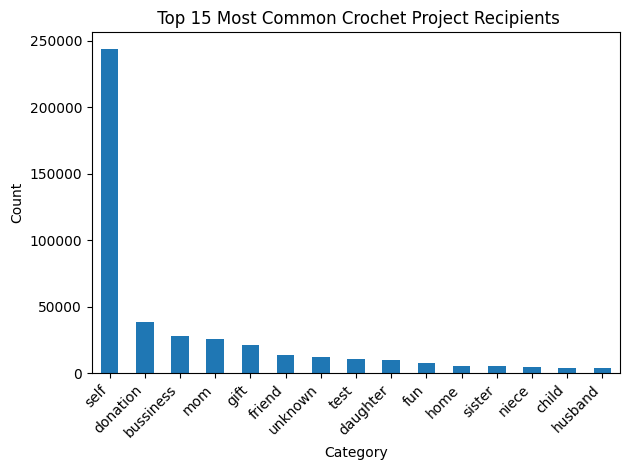

In [ ]:
#plot top 15
counts = clean.value_counts().head(15)

counts.plot(kind='bar',)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title(' Top 15 Most Common Crochet Project Recipients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<positron-console-cell-68>:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


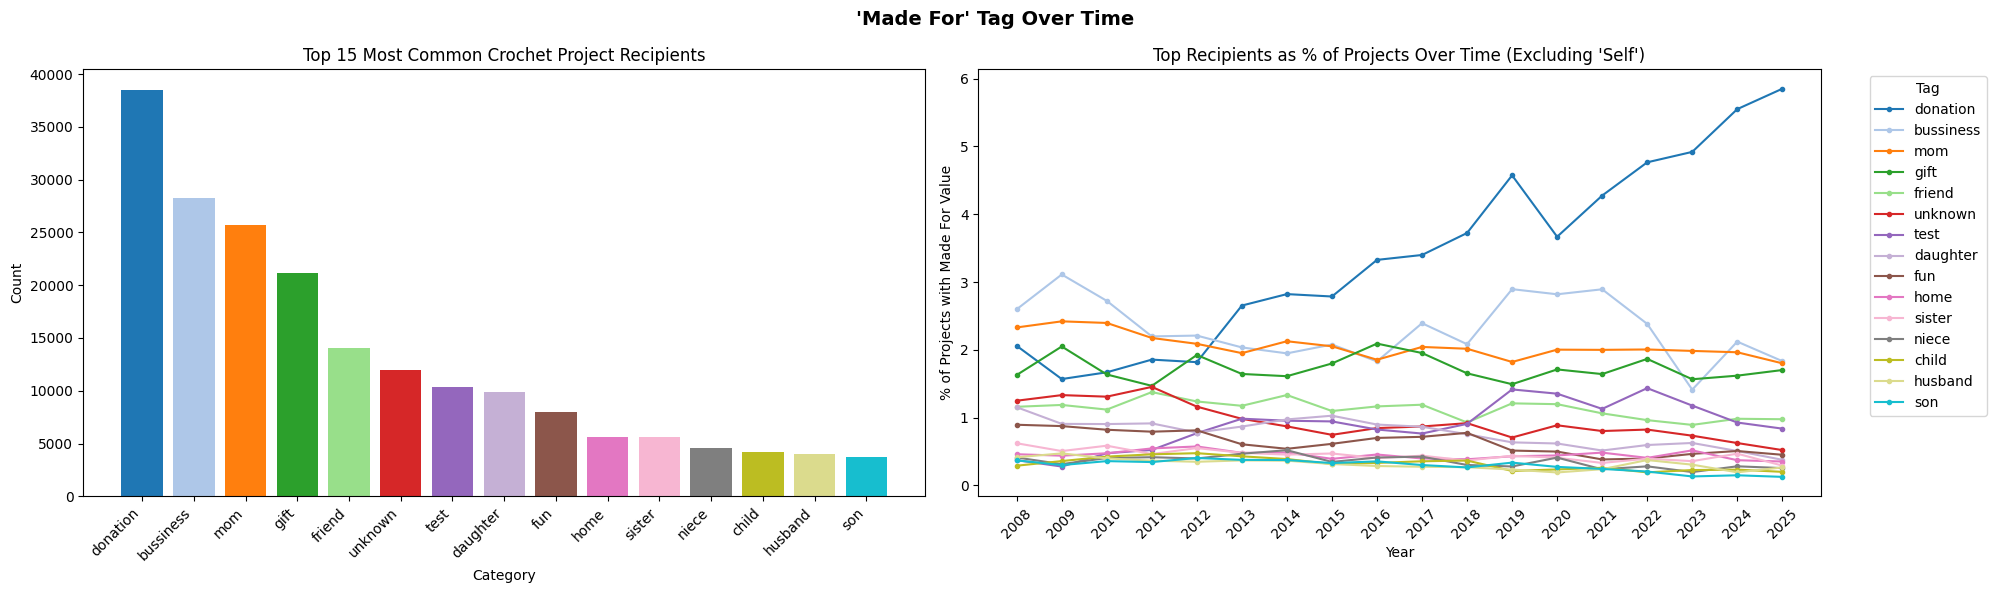

In [ ]:
# color map for top 15 tags
top15 = [tag for tag in clean.value_counts().index if tag != 'self'][:15]
tag_cmap = plt.cm.tab20
tag_colors = {tag: tag_cmap(i / len(top15)) for i, tag in enumerate(top15)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

counts = clean.value_counts().loc[top15]
ax1.bar(counts.index, counts.values, color=[tag_colors[t] for t in counts.index])
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.set_title('Top 15 Most Common Crochet Project Recipients')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels(counts.index, rotation=45, ha='right')

plot_df = df[~df['year'].isin([2007, 2026])]
has_made_for = plot_df[plot_df['made_for_clean'].notna() & (plot_df['made_for_clean'] != '')]
total_per_year = has_made_for.groupby('year').size()

proportions = {}
for tag in top15:
    tag_per_year = has_made_for[has_made_for['made_for_clean'] == tag].groupby('year').size()
    proportions[tag] = (tag_per_year / total_per_year * 100).fillna(0)

prop_df = pd.DataFrame(proportions).reindex(range(2008, 2026), fill_value=0)

for tag in top15:
    ax2.plot(prop_df.index, prop_df[tag], marker='o', markersize=3,
             color=tag_colors[tag], label=tag)

ax2.set_xlabel("Year")
ax2.set_ylabel("% of Projects with Made For Value")
ax2.set_title("Top Recipients as % of Projects Over Time (Excluding 'Self')")
ax2.set_xticks(range(2008, 2026))
ax2.set_xticklabels(range(2008, 2026), rotation=45)
ax2.legend(title='Tag', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("'Made For' Tag Over Time", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

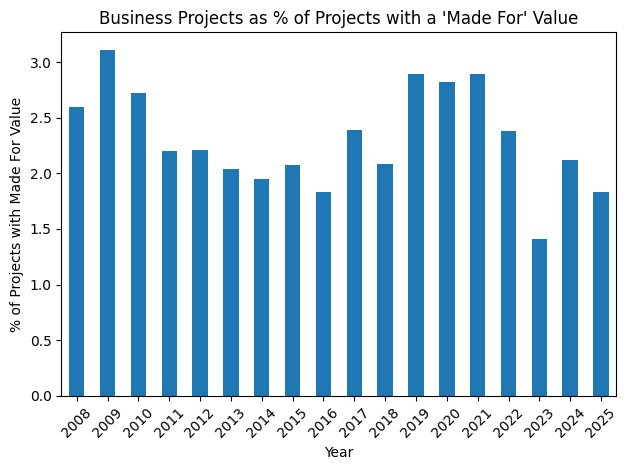

In [60]:
plot_df = df[~df['year'].isin([2007, 2026])]

# Only projects where made_for has a value
has_made_for = plot_df[plot_df['made_for_clean'].notna() & (plot_df['made_for_clean'] != '')]

total_per_year = has_made_for.groupby('year').size()
business_per_year = has_made_for[has_made_for['made_for_clean'] == 'bussiness'].groupby('year').size()

business_pct = (business_per_year / total_per_year * 100).fillna(0)

plt.figure()
business_pct.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("% of Projects with Made For Value")
plt.title("Business Projects as % of Projects with a 'Made For' Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

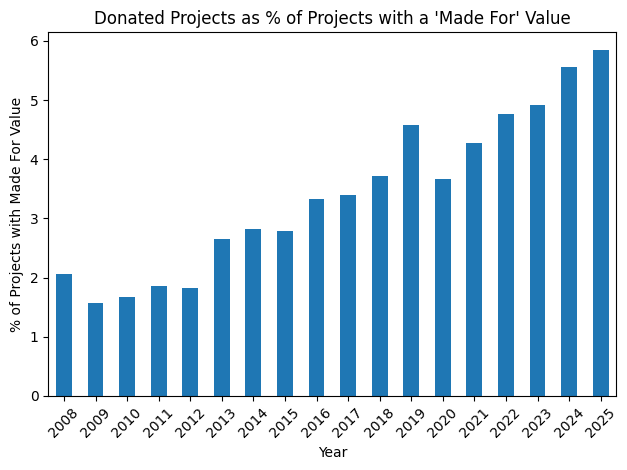

In [61]:
plot_df = df[~df['year'].isin([2007, 2026])]

# Only projects where made_for has a value
has_made_for = plot_df[plot_df['made_for_clean'].notna() & (plot_df['made_for_clean'] != '')]

total_per_year = has_made_for.groupby('year').size()
business_per_year = has_made_for[has_made_for['made_for_clean'] == 'donation'].groupby('year').size()

business_pct = (business_per_year / total_per_year * 100).fillna(0)

plt.figure()
business_pct.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("% of Projects with Made For Value")
plt.title("Donated Projects as % of Projects with a 'Made For' Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
# color map
years = list(range(2008, 2026))
cmap = plt.cm.tab20
colors = {year: cmap(i / len(years)) for i, year in enumerate(years)}

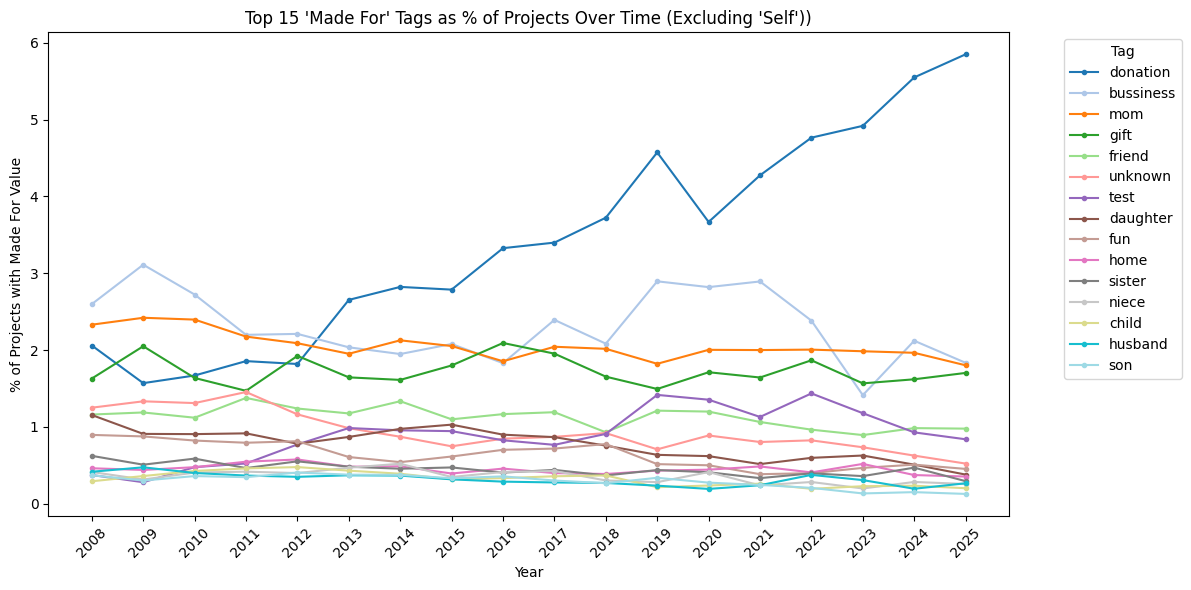

In [ ]:
# Get top 15 tags excluding 'self'
top15 = [tag for tag in clean.value_counts().index if tag != 'self'][:15]

plot_df = df[~df['year'].isin([2007, 2026])]

# Only projects where made_for has a value
has_made_for = plot_df[plot_df['made_for_clean'].notna() & (plot_df['made_for_clean'] != '')]
total_per_year = has_made_for.groupby('year').size()

# For each top 15 tag, compute % per year
proportions = {}
for tag in top15:
    tag_per_year = has_made_for[has_made_for['made_for_clean'] == tag].groupby('year').size()
    proportions[tag] = (tag_per_year / total_per_year * 100).fillna(0)

prop_df = pd.DataFrame(proportions)

# Reindex so x axis shows up proprerly
prop_df = prop_df.reindex(range(2008, 2026), fill_value=0)

# Line plot
fig, ax = plt.subplots(figsize=(12, 6))
prop_df.plot(kind='line', ax=ax, marker='o', markersize=3, cmap='tab20')

plt.xlabel("Year")
plt.ylabel("% of Projects with Made For Value")
plt.title("Top 15 'Made For' Tags as % of Projects Over Time (Excluding 'Self'))")
plt.legend(title='Tag', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks(range(2008, 2026))
ax.set_xticklabels(range(2008, 2026), rotation=45)
plt.tight_layout()
plt.show()

In [63]:
#new column called lag that is the diff between df['created_at'] and df['started'] only for projects that df['started_day_set'] = True
print(df['created_at'].head())
print(df['started_day_set'].head())
print(df['started'].head())

0    2024/11/19 18:11:15 -0500
1    2018/07/13 15:37:08 -0400
2    2016/09/03 17:49:40 -0400
3    2020/08/30 15:43:09 -0400
4    2015/04/01 22:01:30 -0400
Name: created_at, dtype: object
0    False
1     True
2    False
3     True
4    False
Name: started_day_set, dtype: bool
0           NaN
1    2018/07/13
2           NaN
3    2020/08/26
4           NaN
Name: started, dtype: object


In [ ]:
# color map
years = list(range(2008, 2026))
cmap = plt.cm.tab20
colors = {year: cmap(i / len(years)) for i, year in enumerate(years)}

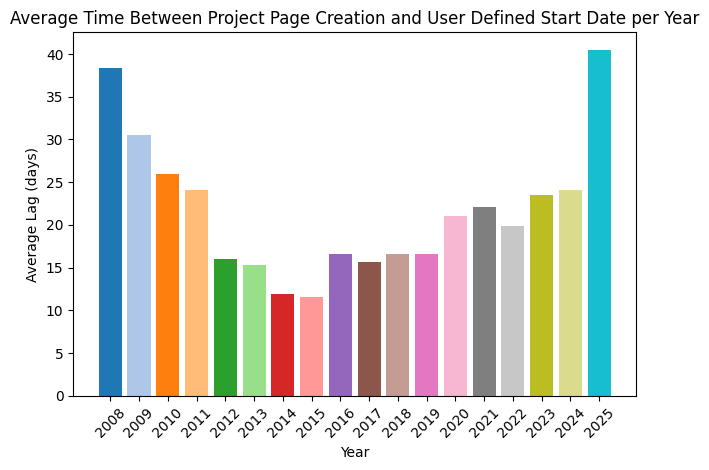

In [ ]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag in days
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]
avg_lag_per_year = plot_df.groupby('year')['lag_days'].mean()

#  shared colors
bar_colors = [colors[y] for y in avg_lag_per_year.index if y in colors]

fig, ax = plt.subplots()
ax.bar(avg_lag_per_year.index.astype(str), avg_lag_per_year.values, color=bar_colors)

plt.xlabel("Year")
plt.ylabel("Average Lag (days)")
plt.title("Average Time Between Project Page Creation and User Defined Start Date per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

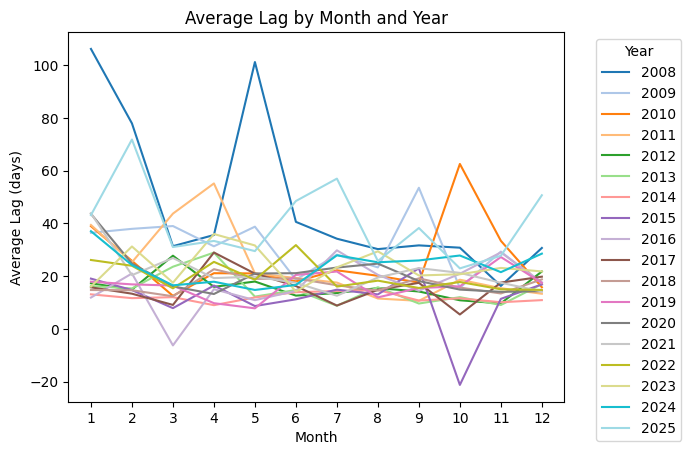

In [ ]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

plot_df = df[~df['year'].isin([2007, 2026])]
grouped = plot_df.groupby(['year', 'month'])['lag_days'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='lag_days')


plt.figure()
pivot.plot(kind='line', cmap='tab20')

plt.xlabel("Month")
plt.ylabel("Average Lag (days)")
plt.title("Average Lag by Month and Year")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<Figure size 640x480 with 0 Axes>

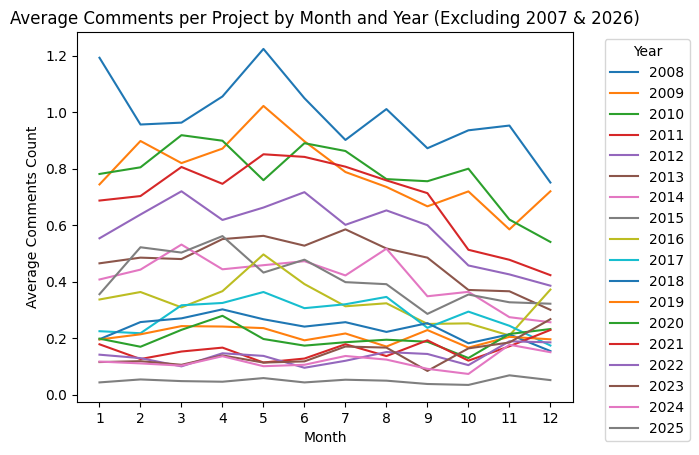

In [ ]:
# Extract year and month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# leave out incomplete years
df_filtered = df[~df['year'].isin([2007, 2026])]

grouped = df_filtered.groupby(['year', 'month'])['comments_count'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='comments_count')

# Plot
plt.figure()
pivot.plot()

plt.xlabel("Month")
plt.ylabel("Average Comments Count")
plt.title("Average Comments per Project by Month and Year (Excluding 2007 & 2026)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

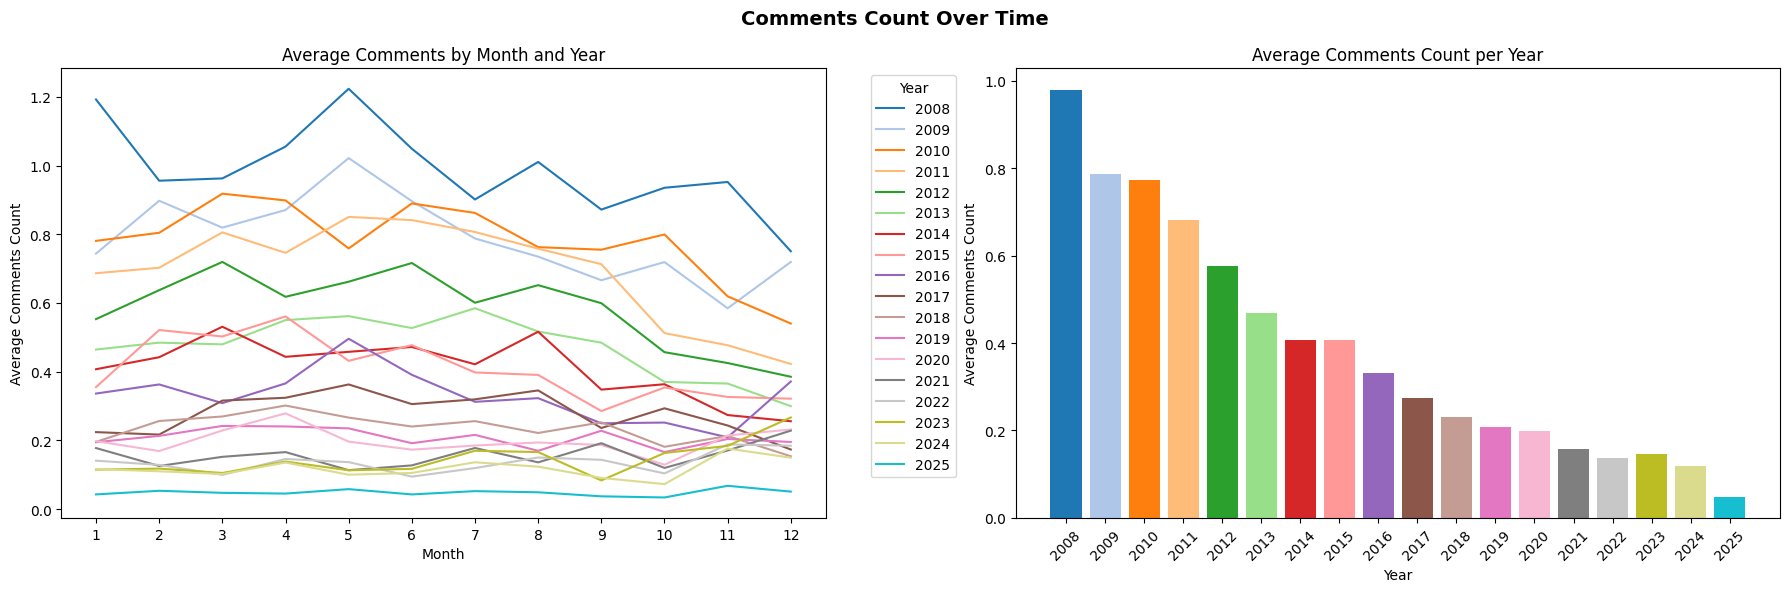

In [ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))


df['month'] = df['created_at_dt'].dt.month
df_filtered = df[~df['year'].isin([2007, 2026])]


grouped = df_filtered.groupby(['year', 'month'])['comments_count'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='comments_count')

for year in pivot.columns:
    if year in colors:
        ax1.plot(pivot.index, pivot[year], label=str(year), color=colors[year])

ax1.set_xlabel("Month")
ax1.set_ylabel("Average Comments Count")
ax1.set_title("Average Comments by Month and Year")
ax1.set_xticks(range(1, 13))
ax1.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

avg_per_year = df_filtered.groupby('year')['comments_count'].mean()
bar_colors = [colors[y] for y in avg_per_year.index if y in colors]
ax2.bar(avg_per_year.index.astype(str), avg_per_year.values, color=bar_colors)

ax2.set_xlabel("Year")
ax2.set_ylabel("Average Comments Count")
ax2.set_title("Average Comments Count per Year")
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("Comments Count Over Time", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

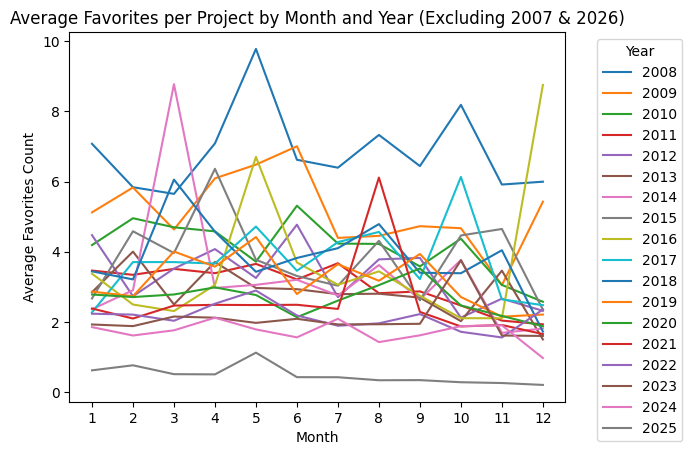

In [ ]:
#are favorites count increasing over time
# Extract year and month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# leave out incomplete years
df_filtered = df[~df['year'].isin([2007, 2026])]


grouped = df_filtered.groupby(['year', 'month'])['favorites_count'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='favorites_count')


plt.figure()
pivot.plot()

plt.xlabel("Month")
plt.ylabel("Average Favorites Count")
plt.title("Average Favorites per Project by Month and Year (Excluding 2007 & 2026)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

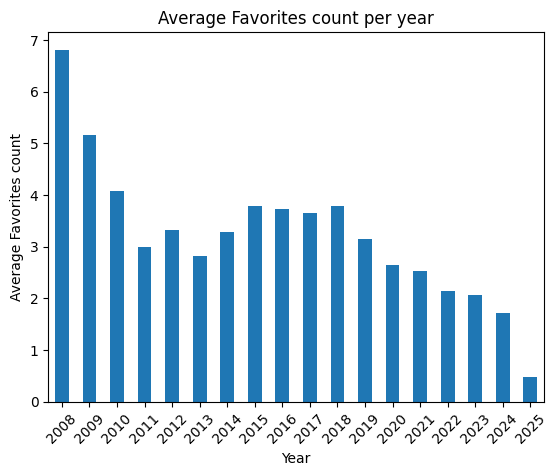

In [ ]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]

avg_per_year = plot_df.groupby('year')['favorites_count'].mean()

plt.figure()
avg_per_year.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Favorites count")
plt.title("Average Favorites count per year")
plt.xticks(rotation=45)
plt.show()

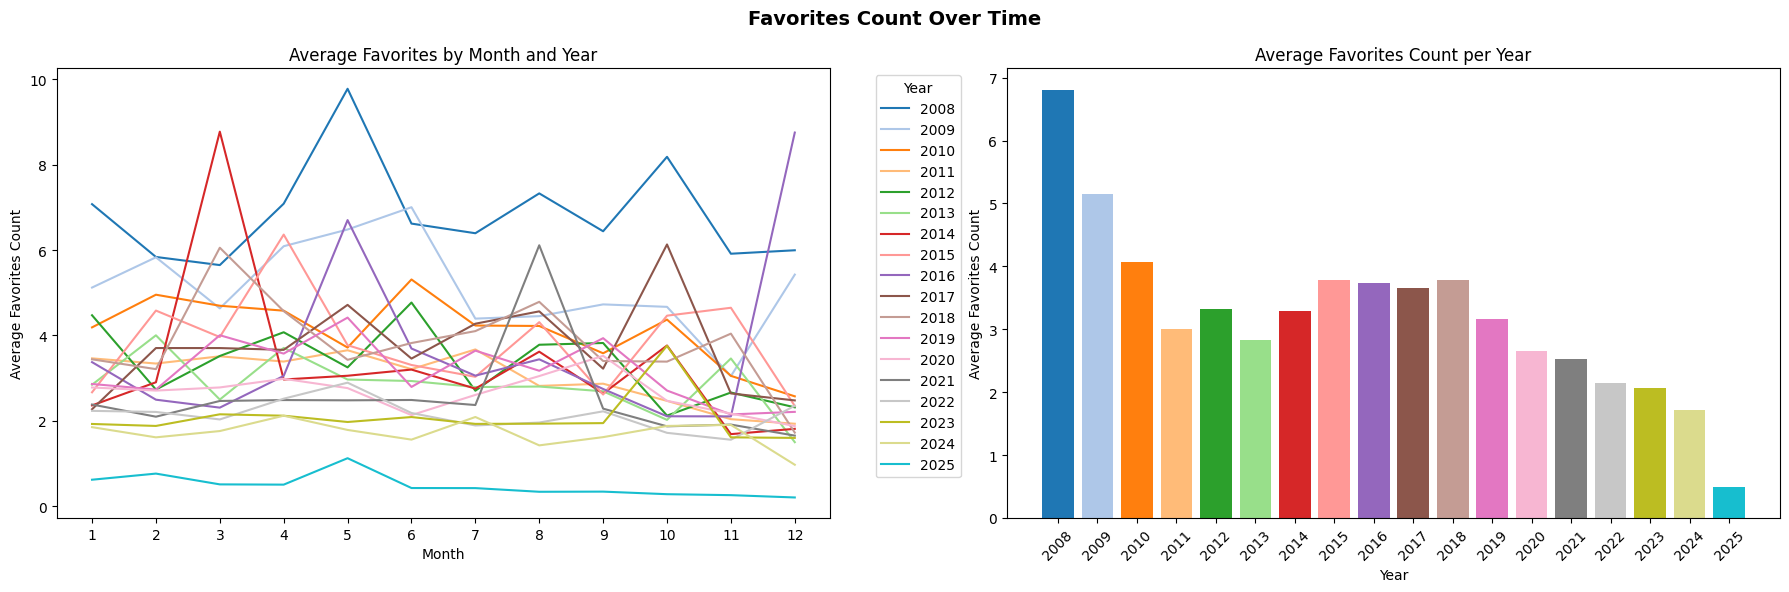

In [ ]:
# color map
years = list(range(2008, 2026))
cmap = plt.cm.tab20
colors = {year: cmap(i / len(years)) for i, year in enumerate(years)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))


df['month'] = df['created_at_dt'].dt.month
df_filtered = df[~df['year'].isin([2007, 2026])]


grouped = df_filtered.groupby(['year', 'month'])['favorites_count'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='favorites_count')

for year in pivot.columns:
    if year in colors:
        ax1.plot(pivot.index, pivot[year], label=str(year), color=colors[year])

ax1.set_xlabel("Month")
ax1.set_ylabel("Average Favorites Count")
ax1.set_title("Average Favorites by Month and Year")
ax1.set_xticks(range(1, 13))
ax1.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

avg_per_year = df_filtered.groupby('year')['favorites_count'].mean()
bar_colors = [colors[y] for y in avg_per_year.index if y in colors]
ax2.bar(avg_per_year.index.astype(str), avg_per_year.values, color=bar_colors)

ax2.set_xlabel("Year")
ax2.set_ylabel("Average Favorites Count")
ax2.set_title("Average Favorites Count per Year")
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("Favorites Count Over Time", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

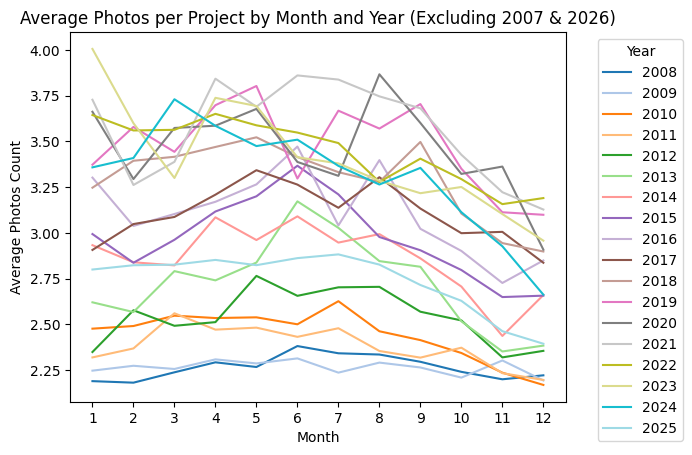

In [ ]:
#how about photos_count
#are favorites count increasing over time
# Extract year and month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# leave out incomplete years
df_filtered = df[~df['year'].isin([2007, 2026])]


grouped = df_filtered.groupby(['year', 'month'])['photos_count'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='photos_count')


plt.figure()
pivot.plot(kind='line', cmap='tab20')

plt.xlabel("Month")
plt.ylabel("Average Photos Count")
plt.title("Average Photos per Project by Month and Year (Excluding 2007 & 2026)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

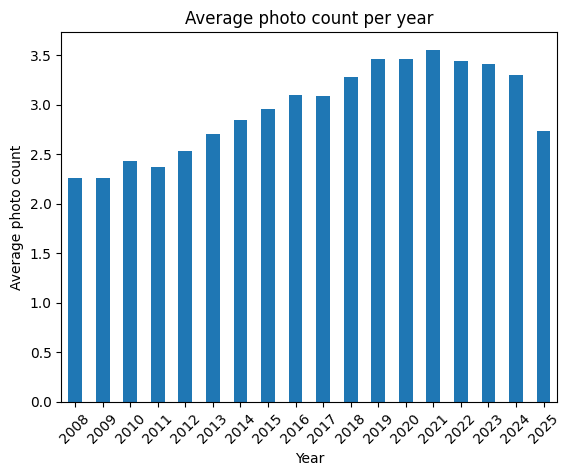

In [ ]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]

avg_per_year = plot_df.groupby('year')['photos_count'].mean()


plt.figure()
avg_per_year.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Photo count")
plt.title("Average Photo count per year")
plt.xticks(rotation=45)
plt.show()

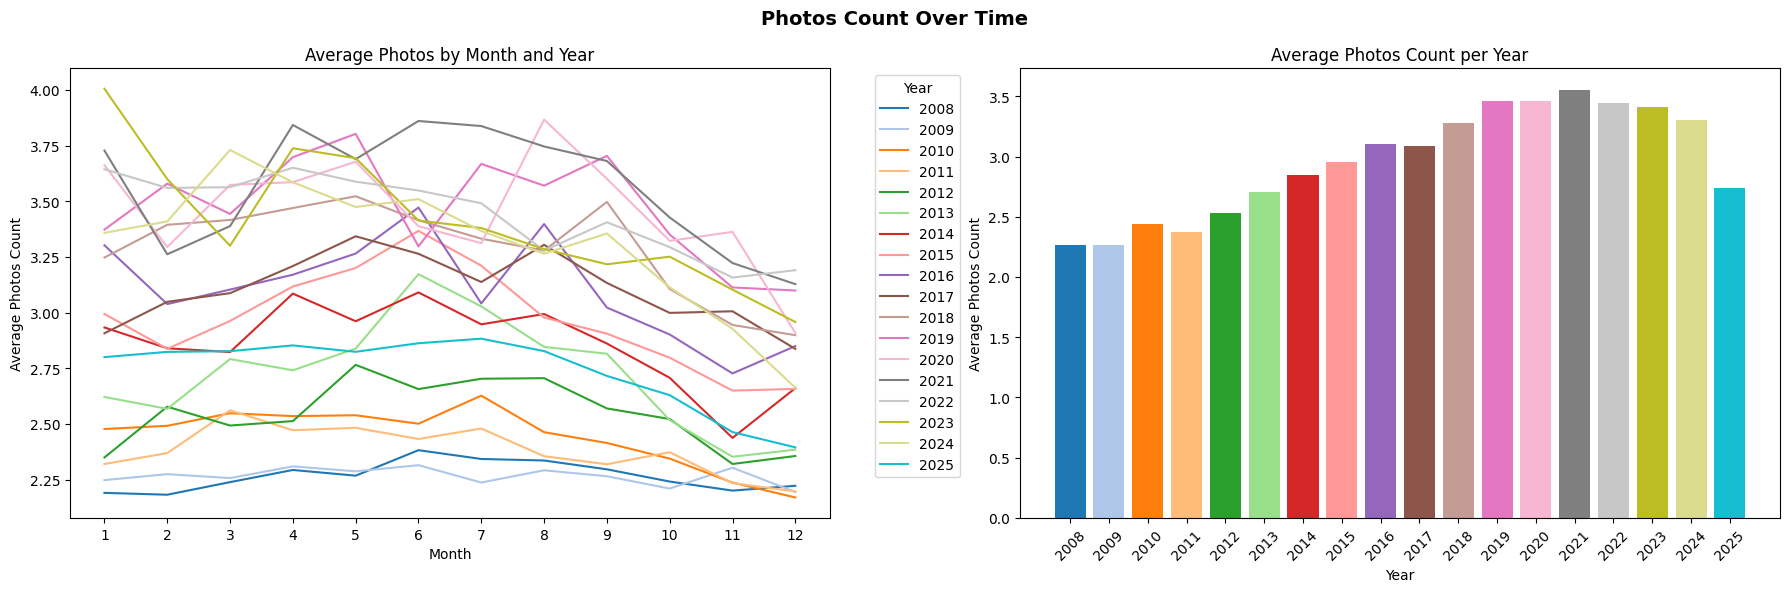

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

df['month'] = df['created_at_dt'].dt.month
df_filtered = df[~df['year'].isin([2007, 2026])]

grouped = df_filtered.groupby(['year', 'month'])['photos_count'].mean().reset_index()
pivot = grouped.pivot(index='month', columns='year', values='photos_count')

for year in pivot.columns:
    if year in colors:
        ax1.plot(pivot.index, pivot[year], label=str(year), color=colors[year])

ax1.set_xlabel("Month")
ax1.set_ylabel("Average Photos Count")
ax1.set_title("Average Photos by Month and Year")
ax1.set_xticks(range(1, 13))
ax1.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')


avg_per_year = df_filtered.groupby('year')['photos_count'].mean()
bar_colors = [colors[y] for y in avg_per_year.index if y in colors]
ax2.bar(avg_per_year.index.astype(str), avg_per_year.values, color=bar_colors)

ax2.set_xlabel("Year")
ax2.set_ylabel("Average Photos Count")
ax2.set_title("Average Photos Count per Year")
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("Photos Count Over Time", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()